In [1]:
%load_ext autoreload
%autoreload 2

import os, sys 
sys.path.append("../models")
sys.path.append("../models/src_invariant")
sys.path.append("../models/src_plotting")
# !pip install qutip
from src_invariant.load_all import *
from src_plotting.load_all import *
from qutip import *
import numpy as np
import h5py
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from tqdm import tqdm

In [2]:
params = {
    'time': None,
    'steps': None,
    'base_coupling': None,
    'system_e_levels': None,
    'system_starts': None,
    'photon_starts': [0],
    'photon_freqs': [1],
    'photon_max_nums': [40],
    'spatial': False,
    'couplings': None,
    'model': None,
    'descr': ""
}

chain_length = 1
params['system_e_levels'] = np.array([[0, 1]])

In [5]:
mini = 0
maxi = 4
step = 0.01
eigenstates = 10

In [5]:
params['model'] = 'invariant_dipole_pzw'
systems_dipole_pzw = get_hamiltonians(params, chain_length, mini , maxi, step)

params['model'] = 'invariant_coulomb'
systems_inv_coulomb = get_hamiltonians(params, chain_length, mini , maxi, step)

params['model'] = 'dicke'
systems_dicke = get_hamiltonians(params, chain_length, mini , maxi, step)

params['model'] = 'dicke_diamag'
systems_a2 = get_hamiltonians(params, chain_length, mini , maxi, step)

params['model'] = 'jc'
systems_tavis = get_hamiltonians(params, chain_length, mini , maxi, step)

100%|██████████| 400/400 [00:00<00:00, 2827.28it/s]


100%|██████████| 400/400 [00:02<00:00, 156.45it/s]


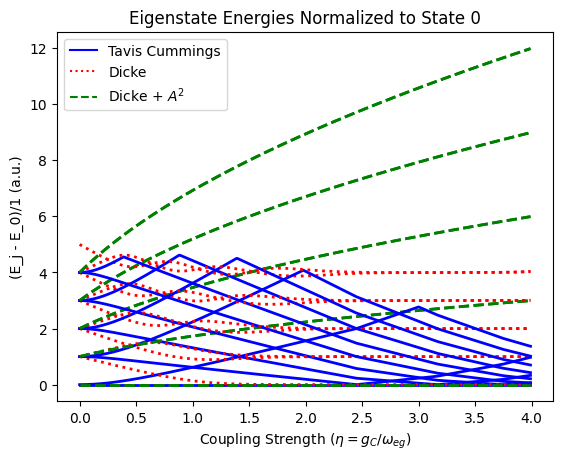

In [6]:
plot_compare([systems_tavis, systems_dicke, systems_a2], 
              [i for i in range(eigenstates)], mini, maxi, step, 
               models_s=["Tavis Cummings", "Dicke", "Dicke + $A^2$"],
              omega=params['photon_freqs'][0], norm_state = 0, xlabel = "Coupling Strength ($\eta = g_C / \omega_{eg}$)")

In [10]:
params = {
    'time': None,
    'steps': None,
    'base_coupling': None,
    'system_e_levels': None,
    'system_starts': None,
    'photon_starts': [0],
    'photon_freqs': [1],
    'photon_max_nums': [40],
    'spatial': False,
    'couplings': None,
    'model': None,
    'descr': ""
}

chain_length = 1
params['system_e_levels'] = np.array([[0, 1]])

100%|██████████| 400/400 [00:02<00:00, 136.52it/s]


ValueError: ';' is not a valid value for ls; supported values are '-', '--', '-.', ':', 'None', ' ', '', 'solid', 'dashed', 'dashdot', 'dotted'

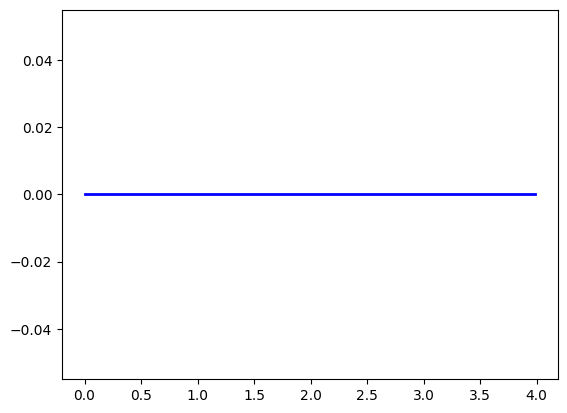

In [11]:
# params['model'] = 'invariant_dipole_pzw'
# systems_dipole_pzw = get_hamiltonians(params, chain_length, mini , maxi, step)

# params['model'] = 'dicke_diamag'
# systems_a2 = get_hamiltonians(params, chain_length, mini , maxi, step)

# params['model'] = 'invariant_coulomb'
# systems_inv_coulomb = get_hamiltonians(params, chain_length, mini , maxi, step)

plot_compare([systems_dipole_pzw, systems_inv_coulomb, systems_a2], 
              [i for i in range(eigenstates)], mini, maxi, step, models_s=["Dipole", "Invariant Coulomb", "Coulomb"],
              omega=params['photon_freqs'][0], norm_state = 0, xlabel = "Coupling Strength ($\eta$)",
            title="")